In [ ]:
!unzip /content/Composer_Dataset.zip

In [ ]:
pip install music21 pandas matplotlib seaborn pretty-midi


In [ ]:
# Imports
from music21 import converter
import pandas as pd
import pretty_midi
import glob
from typing import Optional
import numpy as np
from typing import Dict
from mido import KeySignatureError
import os
import pretty_midi as pm
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# from music21 import converter
# import pandas as pd

# Load the MIDI file
midi_stream = converter.parse('/content/Composer_Dataset/NN_midi_files_extended/train/bach/bach342.mid')

# Extract musical elements (notes and chords)
data = []
for element in midi_stream.flat.notesAndRests:
    if element.isNote:
        data.append({
            'start_time': element.offset,
            'pitch': element.pitch.midi,
            'duration': element.duration.quarterLength,
            'velocity': element.volume.velocity
        })

# Convert to a Pandas DataFrame
df = pd.DataFrame(data)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   start_time  3614 non-null   object
 1   pitch       3614 non-null   int64 
 2   duration    3614 non-null   object
 3   velocity    3614 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 113.1+ KB
None


/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


In [ ]:
# import pretty_midi

# Load the MIDI file
midi_data = pretty_midi.PrettyMIDI('/content/Composer_Dataset/NN_midi_files_extended/train/bach/bach342.mid')

# Extract tempo changes and time signatures
tempos = midi_data.get_tempo_changes()
print(f"Tempos: {tempos}")

# Extract pitch, start/end time, and velocity for all notes
for instrument in midi_data.instruments:
    for note in instrument.notes:
        print(f"Pitch: {note.pitch}, Start: {note.start}, End: {note.end}, Velocity: {note.velocity}")


In [29]:
# import glob
# import pandas as pd
# from typing import Optional

def load_midi_files(limit: Optional[int] = None) -> pd.DataFrame:
    # Find all MIDI files recursively in the train directory
    midi_files = glob.glob('/content/Composer_Dataset/NN_midi_files_extended/train/**/*.mid', recursive=True)

    if limit:
        print(f'Limiting to {limit} files')
        midi_files = midi_files[:limit]

    print(f'Parsing {len(midi_files)} midi files...')

    # Using the parse_midi_file function
    midi_meta = [parse_midi_file(f) for f in midi_files]

    print('Finished parsing midi files.')

    return pd.DataFrame(midi_meta)

# Parse all files (this might take a few moments)
midi_df = load_midi_files(limit=None)
midi_df.head()

Parsing 369 midi files...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Finished parsing midi files.


,midi_path,midi_error,estimate_tempo,tempi_sec,tempi,end_time,drums,resolution,instrument_names,num_time_signature_changes,proto_path
0,/content/Composer_Dataset/NN_midi_files_extend...,False,193.333382,"[0.0, 135.862035, 136.672845, 137.625225, 139....","[87.00002175000543, 74.000074000074, 63.000063...",150.532134,False,96,"[Hummel Op.7-1 , Hummel Op.7-1 , Hummel Op.7-1 ]",1,/content/Composer_Dataset/NN_midi_files_extend...
1,/content/Composer_Dataset/NN_midi_files_extend...,False,155.810464,"[0.0, 2.0, 2.48, 6.570907999999999, 8.192529, ...","[120.0, 250.0, 44.000011733336464, 37.00001418...",327.273358,False,96,"[, , , ]",3,/content/Composer_Dataset/NN_midi_files_extend...
2,/content/Composer_Dataset/NN_midi_files_extend...,False,186.046803,"[0.0, 3.0, 44.050000000000004, 44.74230775, 45...","[120.0, 80.0, 64.99999458333379, 50.0, 25.0, 8...",2039.810595,False,120,[],18,/content/Composer_Dataset/NN_midi_files_extend...
3,/content/Composer_Dataset/NN_midi_files_extend...,False,211.523906,"[0.0, 2.0, 5.75, 6.481707, 7.195992, 7.8936660...","[120.0, 80.0, 82.00003553334874, 84.0000840000...",487.259974,False,96,[],0,/content/Composer_Dataset/NN_midi_files_extend...
4,/content/Composer_Dataset/NN_midi_files_extend...,False,193.740501,"[0.0, 6.0, 36.076358812500004, 36.609692145833...","[120.0, 90.00009000009, 75.0, 60.0, 30.0, 60.0...",780.186469,False,960,"[Hummel Variations,op.2-2]",3,/content/Composer_Dataset/NN_midi_files_extend...


In [30]:
# import glob
# import numpy as np

midi_files = glob.glob('/content/Composer_Dataset/NN_midi_files_extended/train/**/*.mid')
print(f'Found {len(midi_files)} midi files in dataset')

# # select 5 random files
# np.random.choice(midi_files, 5)

# Confirming all files are reachable
missed_files = set(glob.glob('/content/Composer_Dataset/NN_midi_files_extended/train/**/*.*', recursive=True)) - set(midi_files)
print(f'Did not match {len(missed_files)} files')

Found 369 midi files in dataset
Did not match 0 files


In [44]:
TRAIN_PATH = '/content/Composer_Dataset/NN_midi_files_extended/train'

# make sure that the folder we want to save to actually exists
os.makedirs(TRAIN_PATH, exist_ok=True)

In [45]:
# from typing import Dict
# from mido import KeySignatureError
# import os
# import pretty_midi as pm


# import note_seq # Uncomment and install if you intend to use note_seq

def parse_midi_file(midi_file_path: str, TRAIN_PATH: str=TRAIN_PATH) -> Dict:
    r = {
        'midi_path': midi_file_path,
        'midi_error': True,
    }
    midi_name = os.path.splitext(midi_file_path.split(os.sep)[-1])[0]
    proto_path = os.path.join(TRAIN_PATH, f'{midi_name}.protobuf')

    # r['original_names'] = md5_filenames[midi_name] # Commented out due to NameError: 'md5_filenames' not defined

    try:
        stream = pm.PrettyMIDI(midi_file_path)
        r['midi_error'] = False
    except (OSError, ValueError, IndexError, KeySignatureError, EOFError, ZeroDivisionError):
        return r

    try:
        # r['beat_start'] = stream.estimate_beat_start() # omitted b/c adds 200ms to parsing
        r['estimate_tempo'] = stream.estimate_tempo()
        r['tempi_sec'], r['tempi'] = stream.get_tempo_changes()
        r['end_time'] = stream.get_end_time()
        r['drums'] = any([i.is_drum for i in stream.instruments])
        r['resolution'] = stream.resolution
        r['instrument_names'] = [i.name.strip() for i in stream.instruments]
        r['num_time_signature_changes'] = len(stream.time_signature_changes)
    except ValueError as e:
        # ValueError: Can't estimate beat start when there are no notes.
        # ValueError: Can't provide a global tempo estimate when there are fewer than two notes.
        print(f"Could not parse MIDI file {midi_file_path}: {e}")

    # notes = note_seq.midi_to_note_sequence(stream) # Uncomment and import note_seq if needed
    # with open(proto_path, 'wb') as f:
    #     f.write(notes.SerializeToString())
    r['proto_path'] = proto_path # This line would likely depend on note_seq result

    return r

In [47]:
parse_midi_file('/content/Composer_Dataset/NN_midi_files_extended/train/bach/bach343.mid')

{'midi_path': '/content/Composer_Dataset/NN_midi_files_extended/train/bach/bach343.mid',
 'midi_error': False,
 'estimate_tempo': np.float64(233.93802307170338),
 'tempi_sec': array([0.]),
 'tempi': array([120.]),
 'end_time': np.float64(445.69010416666663),
 'drums': False,
 'resolution': 384,
 'instrument_names': ['', '', '', '', '', '', '', '', '', '', '', ''],
 'num_time_signature_changes': 0,
 'proto_path': '/content/Composer_Dataset/NN_midi_files_extended/train/bach343.protobuf'}

In [40]:
%%timeit

parse_midi_file('/content/Composer_Dataset/NN_midi_files_extended/train/bach/bach342.mid')


185 ms ± 43.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
# import os
# import pandas as pd
# from music21 import converter

def analyze_midi_folder(folder_path):
    all_songs_data = []

    # Iterate through all files in the directory
    for filename in os.listdir(folder_path):
        if filename.endswith('.mid') or filename.endswith('.midi'):
            file_path = os.path.join(folder_path, filename)

            try:
                # Parse the file
                score = converter.parse(file_path)
                notes = score.flat.notes

                # Skip files with no note data
                if len(notes) == 0:
                    continue

                # Gather note-specific arrays for quick statistics
                pitches = [n.pitch.midi for n in notes if n.isNote]
                velocities = [n.volume.velocity for n in notes if n.isNote and n.volume.velocity is not None]
                durations = [n.duration.quarterLength for n in notes]

                # Extrapolate metadata if available
                key_sig = score.analyze('key')
                time_sig = score.flat.getElementsByClass('TimeSignature')
                time_sig_str = str(time_sig[0].ratioString) if len(time_sig) > 0 else 'Unknown'

                # Compile a single row for this song
                song_metrics = {
                    'filename': filename,
                    'total_notes': len(notes),
                    'estimated_key': key_sig.name,
                    'estimated_mode': key_sig.mode,
                    'time_signature': time_sig_str,
                    'avg_pitch': sum(pitches) / len(pitches) if pitches else None,
                    'max_pitch': max(pitches) if pitches else None,
                    'min_pitch': min(pitches) if pitches else None,
                    'avg_velocity': sum(velocities) / len(velocities) if velocities else None,
                    'avg_duration': sum(durations) / len(durations) if durations else None,
                }
                all_songs_data.append(song_metrics)

            except Exception as e:
                print(f"Error parsing {filename}: {e}")

    return pd.DataFrame(all_songs_data)


# Usage  ### Running all together is a large job (30 minutes in Colab) ###
df_bach = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/bach')
# df_bartok = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/bartok')
# df_byrd = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/byrd')
# df_chopin = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/chopin')
# df_handel = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/handel')
# df_hummel = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/hummel')
# df_mendelssohn = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/mendelssohn')
# df_mozart = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/mozart')
# df_schumann = analyze_midi_folder('/content/Composer_Dataset/NN_midi_files_extended/train/schumann')


print(df_bach.head())


/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


      filename  total_notes estimated_key estimated_mode time_signature  \
0  bach342.mid         5396       A major          major            4/4   
1  bach357.mid          577       D minor          minor            4/4   
2  bach374.mid         3251       C major          major            4/4   
3  bach355.mid         5669       E minor          minor            4/4   
4  bach388.mid          520       C minor          minor            4/4   

   avg_pitch  max_pitch  min_pitch  avg_velocity  avg_duration  
0  63.269507         84         33         127.0      0.761320  
1  65.310924         82         40         127.0      0.918255  
2  62.813162         84         36         127.0      0.579796  
3  64.899302         84         37         127.0      0.632651  
4  65.875000         82         36         127.0      0.544391  


In [42]:
df_bach.value_counts()

,,,,,,,,,,count
filename,total_notes,estimated_key,estimated_mode,time_signature,avg_pitch,max_pitch,min_pitch,avg_velocity,avg_duration,
bach342.mid,5396,A major,major,4/4,63.269507,84,33,127.0,0.761320,1
bach343.mid,2819,D major,major,4/4,70.362234,83,38,127.0,0.538164,1
bach345.mid,608,G major,major,4/4,63.770624,84,38,127.0,0.751919,1
bach346.mid,583,G minor,minor,4/4,64.306950,84,38,127.0,0.886507,1
bach347.mid,670,A major,major,4/4,62.578616,83,37,127.0,0.411692,1
bach350.mid,7609,D minor,minor,4/4,63.540951,84,36,127.0,0.586082,1
bach351.mid,767,F minor,minor,4/4,64.344380,84,36,127.0,1.057149,1
bach352.mid,341,G major,major,4/4,64.757009,81,40,127.0,0.457234,1
bach353.mid,596,F minor,minor,4/4,63.027897,84,36,127.0,0.577041,1


              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.197518   0.338955  -0.420133           NaN   
avg_pitch        0.197518   1.000000   0.284465   0.240079           NaN   
max_pitch        0.338955   0.284465   1.000000  -0.200406           NaN   
min_pitch       -0.420133   0.240079  -0.200406   1.000000           NaN   
avg_velocity          NaN        NaN        NaN        NaN           NaN   
avg_duration    -0.133342  -0.217472  -0.118071   0.030417           NaN   

              avg_duration  
total_notes      -0.133342  
avg_pitch        -0.217472  
max_pitch        -0.118071  
min_pitch         0.030417  
avg_velocity           NaN  
avg_duration      1.000000  


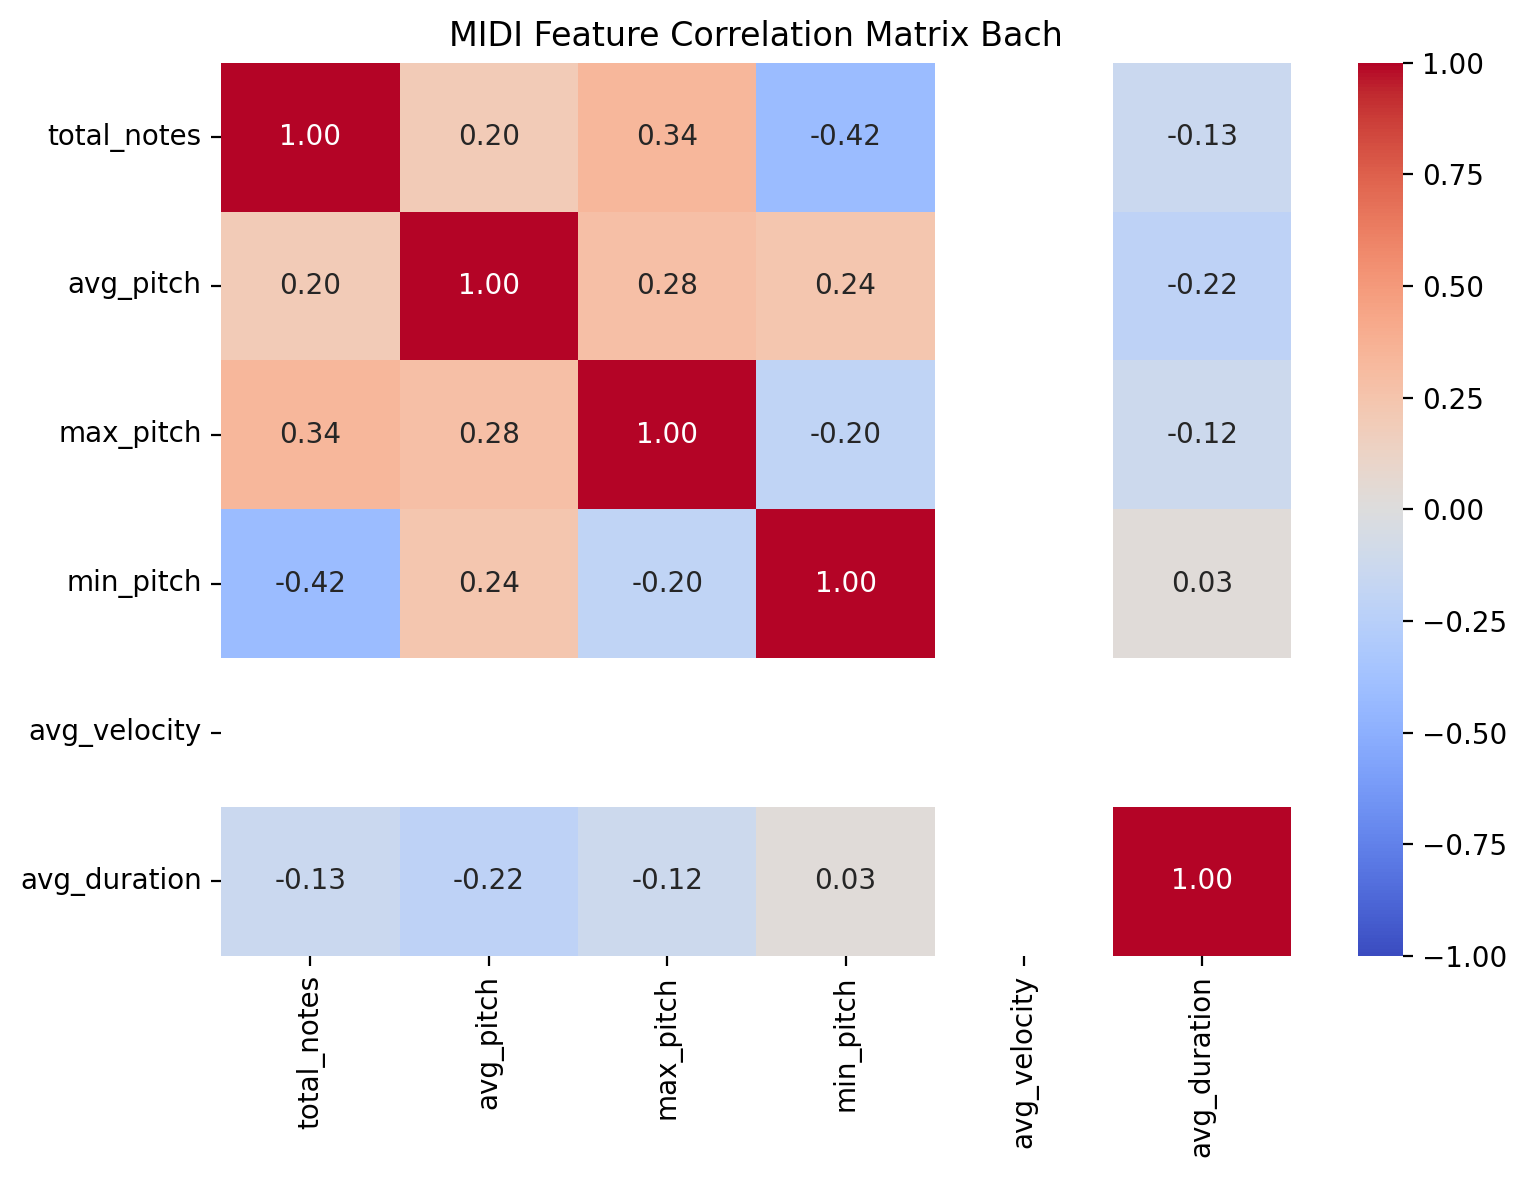

In [18]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# Numerical columns from MIDI DataFrame
numeric_df = df_bach[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Bach')
plt.tight_layout()
plt.show()


              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.041004   0.675680  -0.361862     -0.114256   
avg_pitch        0.041004   1.000000   0.073501   0.488520      0.049225   
max_pitch        0.675680   0.073501   1.000000  -0.630917     -0.130761   
min_pitch       -0.361862   0.488520  -0.630917   1.000000      0.027471   
avg_velocity    -0.114256   0.049225  -0.130761   0.027471      1.000000   
avg_duration    -0.261386  -0.163600  -0.346458   0.184597     -0.271909   

              avg_duration  
total_notes      -0.261386  
avg_pitch        -0.163600  
max_pitch        -0.346458  
min_pitch         0.184597  
avg_velocity     -0.271909  
avg_duration      1.000000  


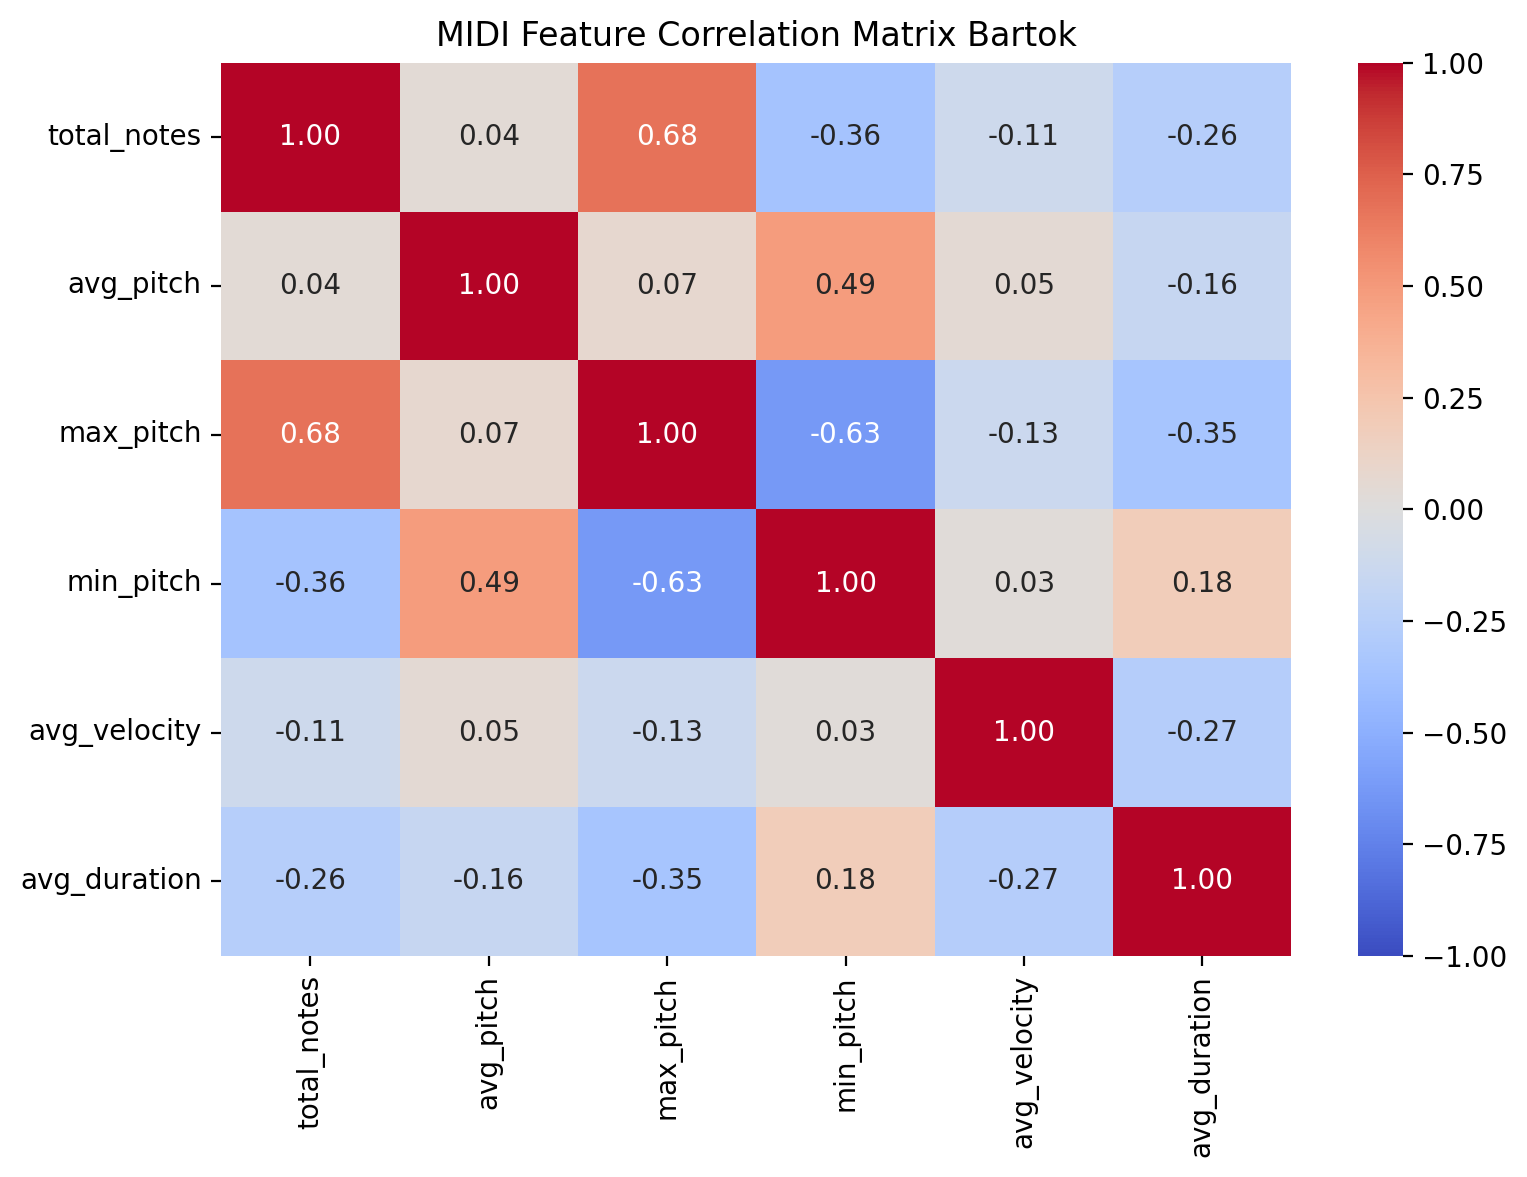

In [17]:
numeric_df = df_bartok[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Bartok')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000  -0.077194   0.397543  -0.140974           NaN   
avg_pitch       -0.077194   1.000000   0.435885   0.344416           NaN   
max_pitch        0.397543   0.435885   1.000000   0.042218           NaN   
min_pitch       -0.140974   0.344416   0.042218   1.000000           NaN   
avg_velocity          NaN        NaN        NaN        NaN           NaN   
avg_duration    -0.335084  -0.210995  -0.422669   0.054830           NaN   

              avg_duration  
total_notes      -0.335084  
avg_pitch        -0.210995  
max_pitch        -0.422669  
min_pitch         0.054830  
avg_velocity           NaN  
avg_duration      1.000000  


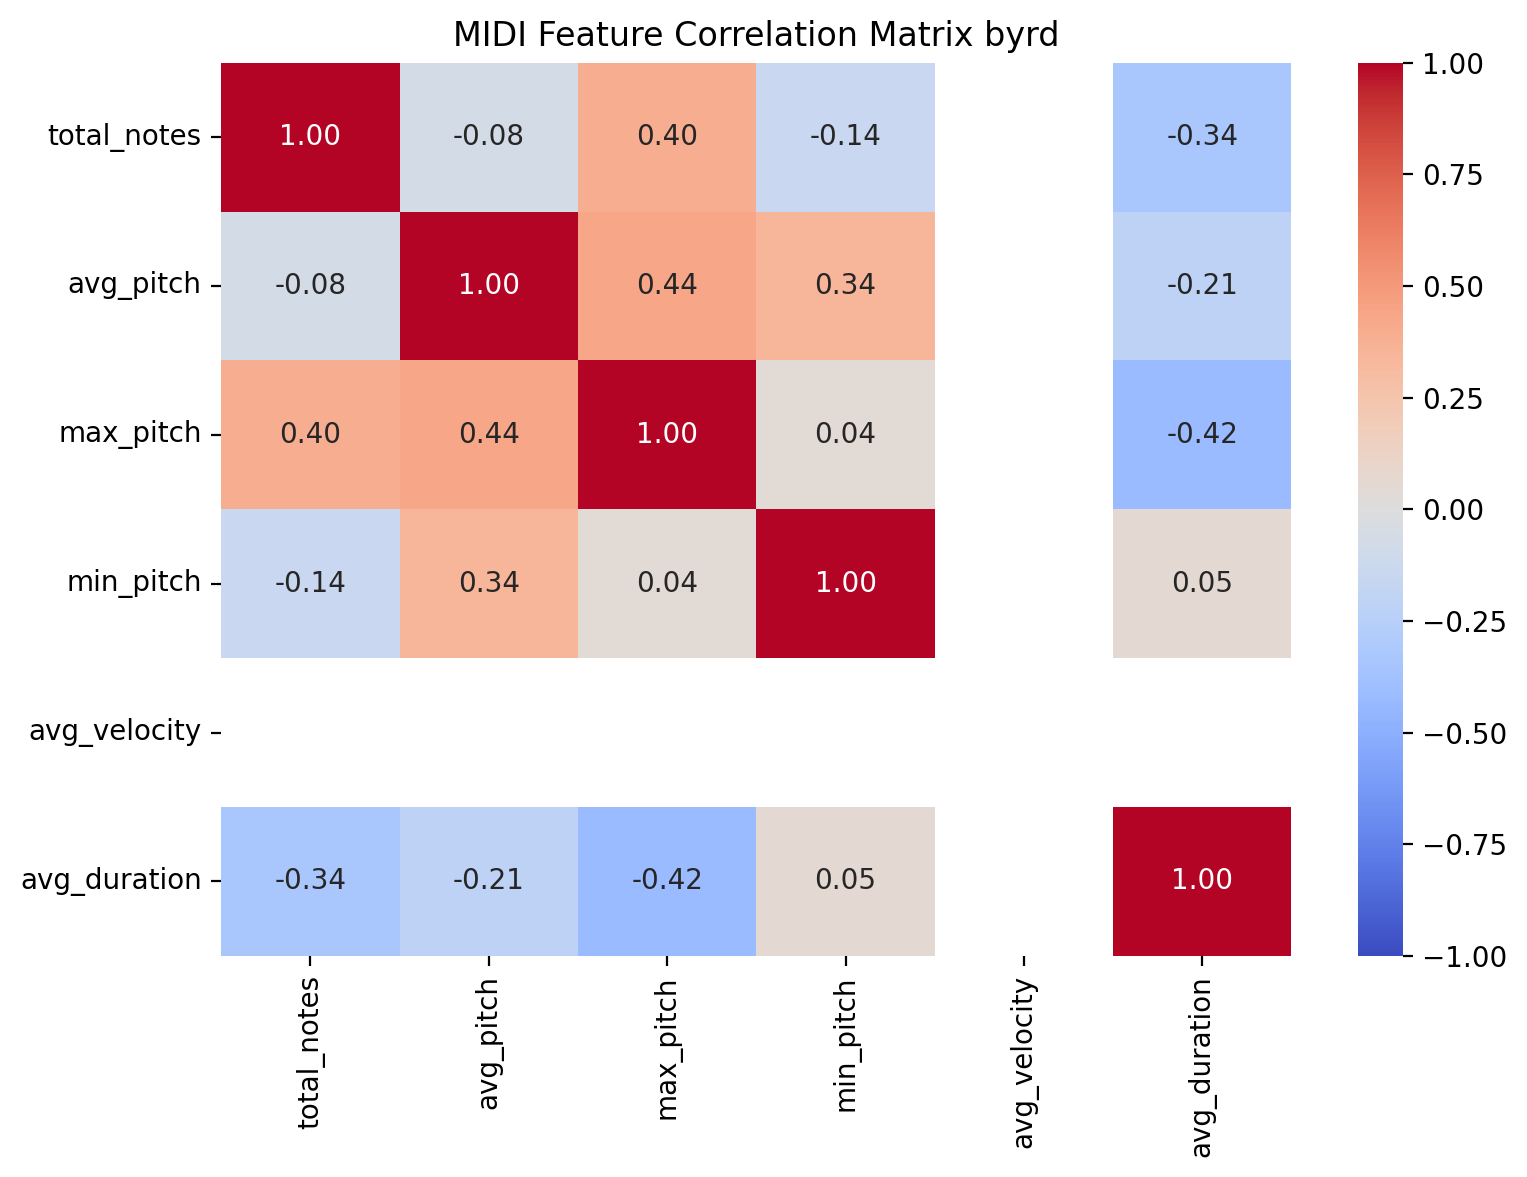

In [23]:
numeric_df = df_byrd[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix byrd')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000  -0.143778   0.317923  -0.736272     -0.110703   
avg_pitch       -0.143778   1.000000   0.260695   0.482010      0.084876   
max_pitch        0.317923   0.260695   1.000000  -0.292052      0.052300   
min_pitch       -0.736272   0.482010  -0.292052   1.000000      0.016207   
avg_velocity    -0.110703   0.084876   0.052300   0.016207      1.000000   
avg_duration     0.129239  -0.342223  -0.221090  -0.247373     -0.616426   

              avg_duration  
total_notes       0.129239  
avg_pitch        -0.342223  
max_pitch        -0.221090  
min_pitch        -0.247373  
avg_velocity     -0.616426  
avg_duration      1.000000  


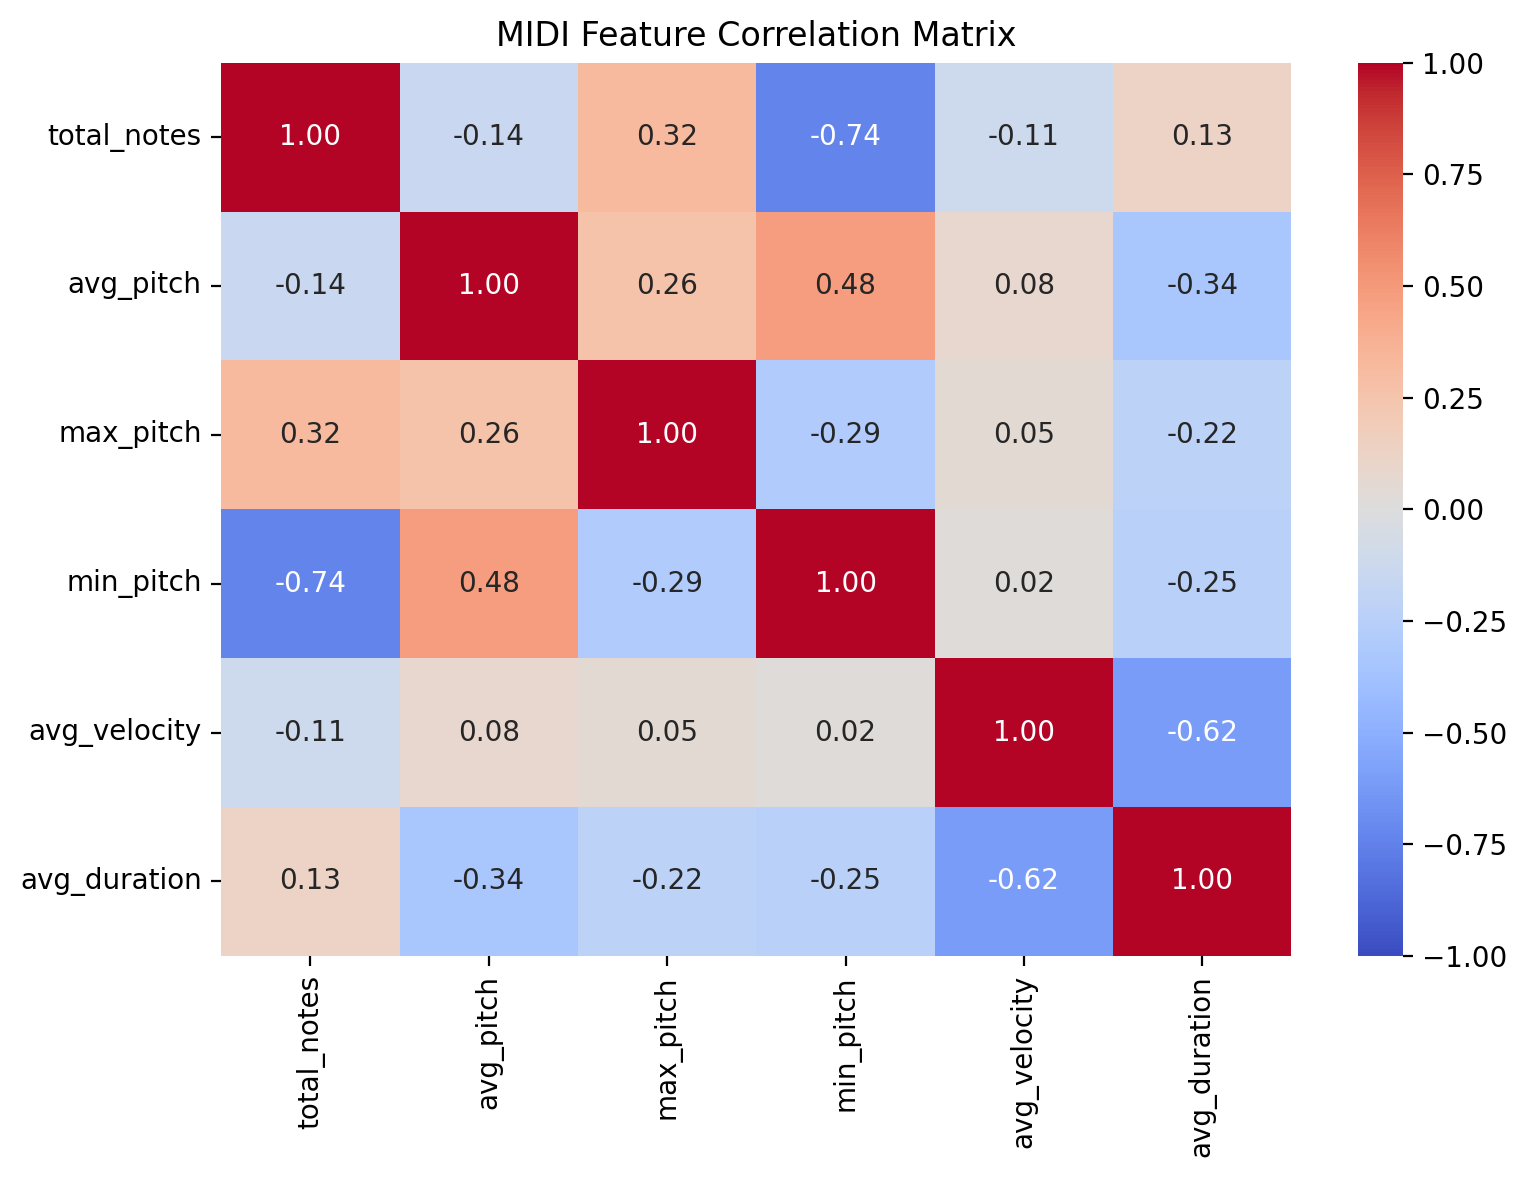

In [24]:
numeric_df = df_chopin[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix chopin')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.343447   0.394499  -0.287157     -0.032697   
avg_pitch        0.343447   1.000000   0.582343   0.427123      0.159363   
max_pitch        0.394499   0.582343   1.000000  -0.045002      0.039868   
min_pitch       -0.287157   0.427123  -0.045002   1.000000      0.458427   
avg_velocity    -0.032697   0.159363   0.039868   0.458427      1.000000   
avg_duration    -0.074064  -0.004516  -0.096064   0.005823      0.187000   

              avg_duration  
total_notes      -0.074064  
avg_pitch        -0.004516  
max_pitch        -0.096064  
min_pitch         0.005823  
avg_velocity      0.187000  
avg_duration      1.000000  


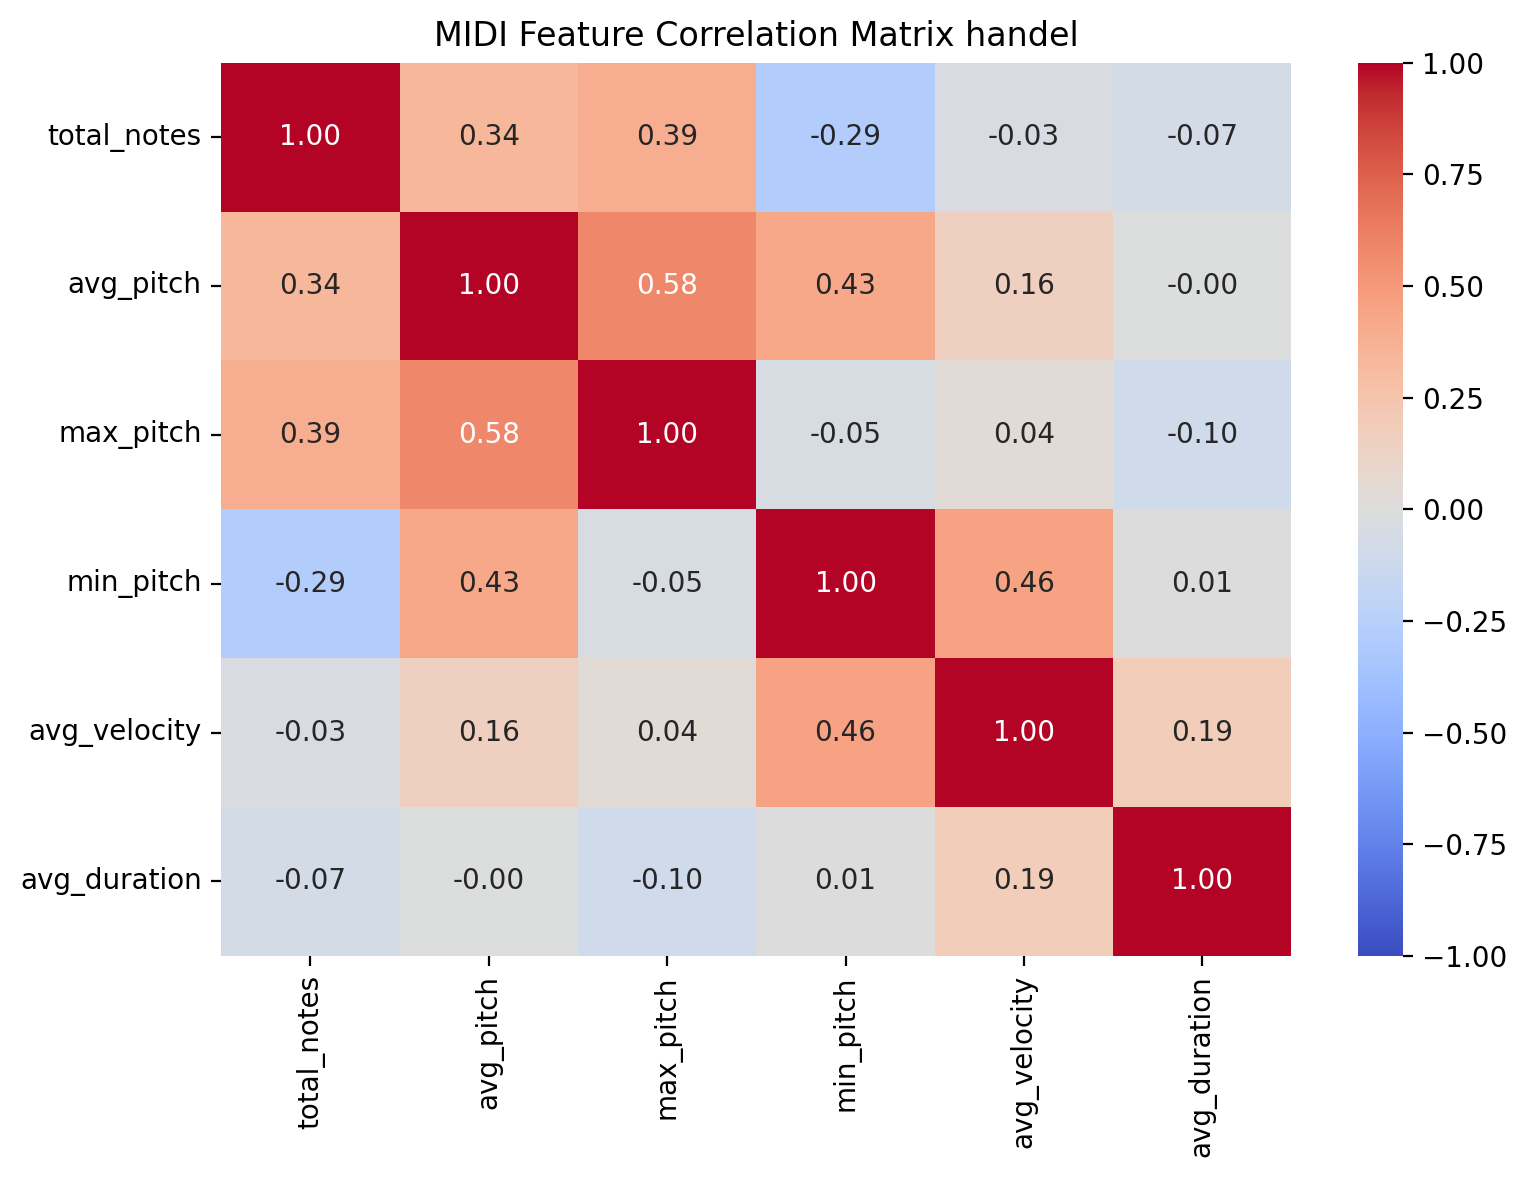

In [26]:
numeric_df = df_handel[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix handel')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.158175   0.415714  -0.339894      0.250365   
avg_pitch        0.158175   1.000000   0.502533   0.182558      0.351161   
max_pitch        0.415714   0.502533   1.000000  -0.341278      0.199679   
min_pitch       -0.339894   0.182558  -0.341278   1.000000     -0.030800   
avg_velocity     0.250365   0.351161   0.199679  -0.030800      1.000000   
avg_duration     0.183449   0.140849   0.097324  -0.077827      0.227113   

              avg_duration  
total_notes       0.183449  
avg_pitch         0.140849  
max_pitch         0.097324  
min_pitch        -0.077827  
avg_velocity      0.227113  
avg_duration      1.000000  


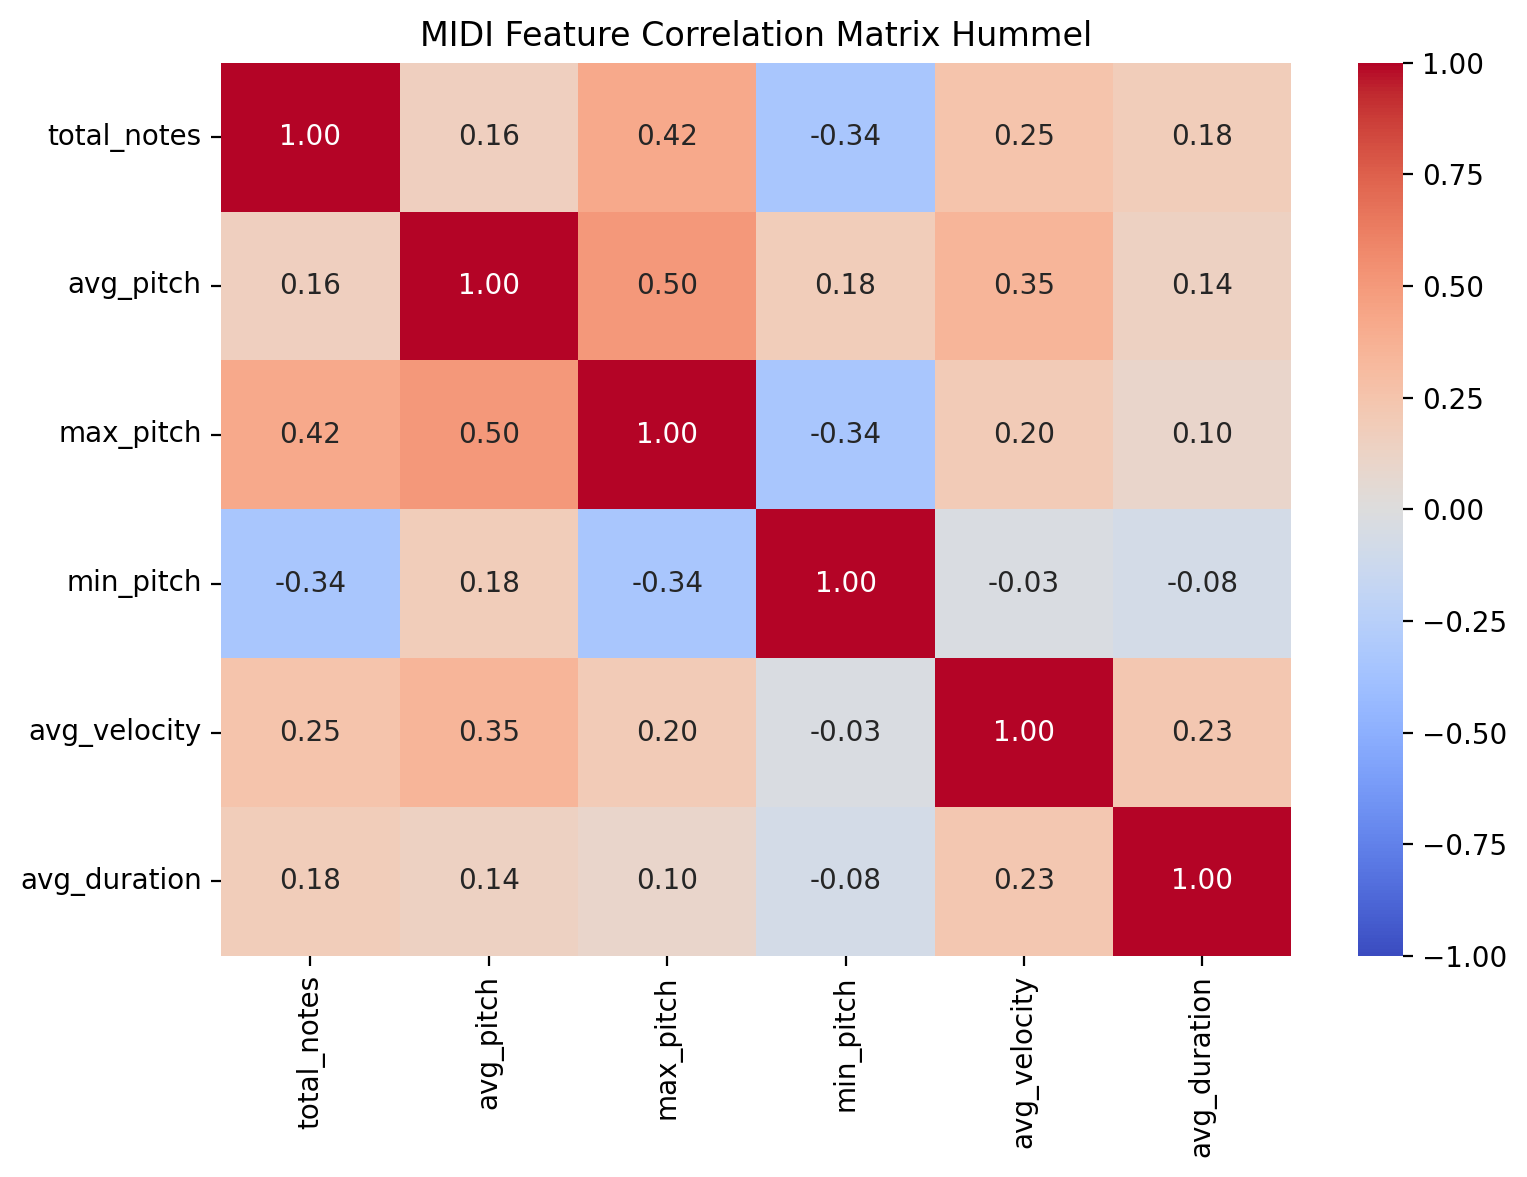

In [25]:
numeric_df = df_hummel[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Hummel')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000  -0.025841   0.092934  -0.514706      0.441432   
avg_pitch       -0.025841   1.000000   0.445260   0.223247      0.309803   
max_pitch        0.092934   0.445260   1.000000  -0.011975     -0.083198   
min_pitch       -0.514706   0.223247  -0.011975   1.000000     -0.288289   
avg_velocity     0.441432   0.309803  -0.083198  -0.288289      1.000000   
avg_duration     0.076232  -0.186165  -0.464780  -0.178626      0.176098   

              avg_duration  
total_notes       0.076232  
avg_pitch        -0.186165  
max_pitch        -0.464780  
min_pitch        -0.178626  
avg_velocity      0.176098  
avg_duration      1.000000  


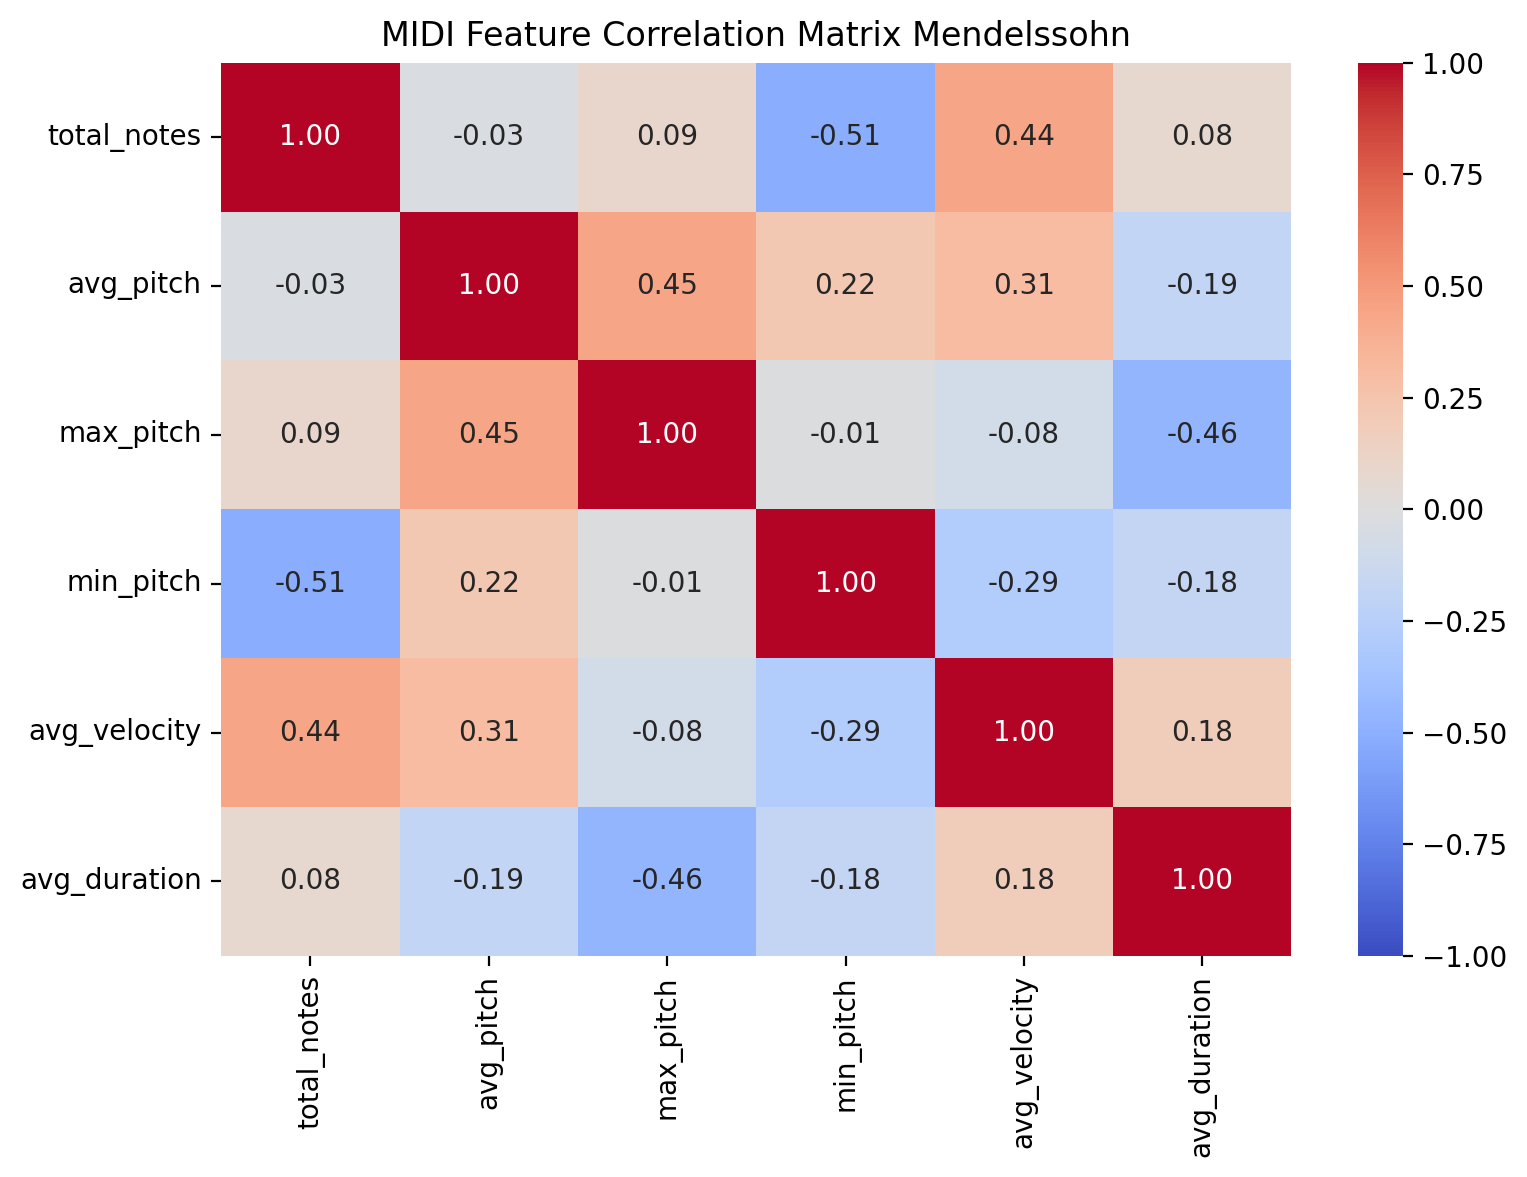

In [28]:
numeric_df = df_mendelssohn[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Mendelssohn')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.108134   0.267281  -0.443204      0.000616   
avg_pitch        0.108134   1.000000   0.566447   0.190938     -0.358077   
max_pitch        0.267281   0.566447   1.000000  -0.376700     -0.277913   
min_pitch       -0.443204   0.190938  -0.376700   1.000000     -0.138359   
avg_velocity     0.000616  -0.358077  -0.277913  -0.138359      1.000000   
avg_duration     0.007924  -0.329536  -0.067123  -0.329695      0.441765   

              avg_duration  
total_notes       0.007924  
avg_pitch        -0.329536  
max_pitch        -0.067123  
min_pitch        -0.329695  
avg_velocity      0.441765  
avg_duration      1.000000  


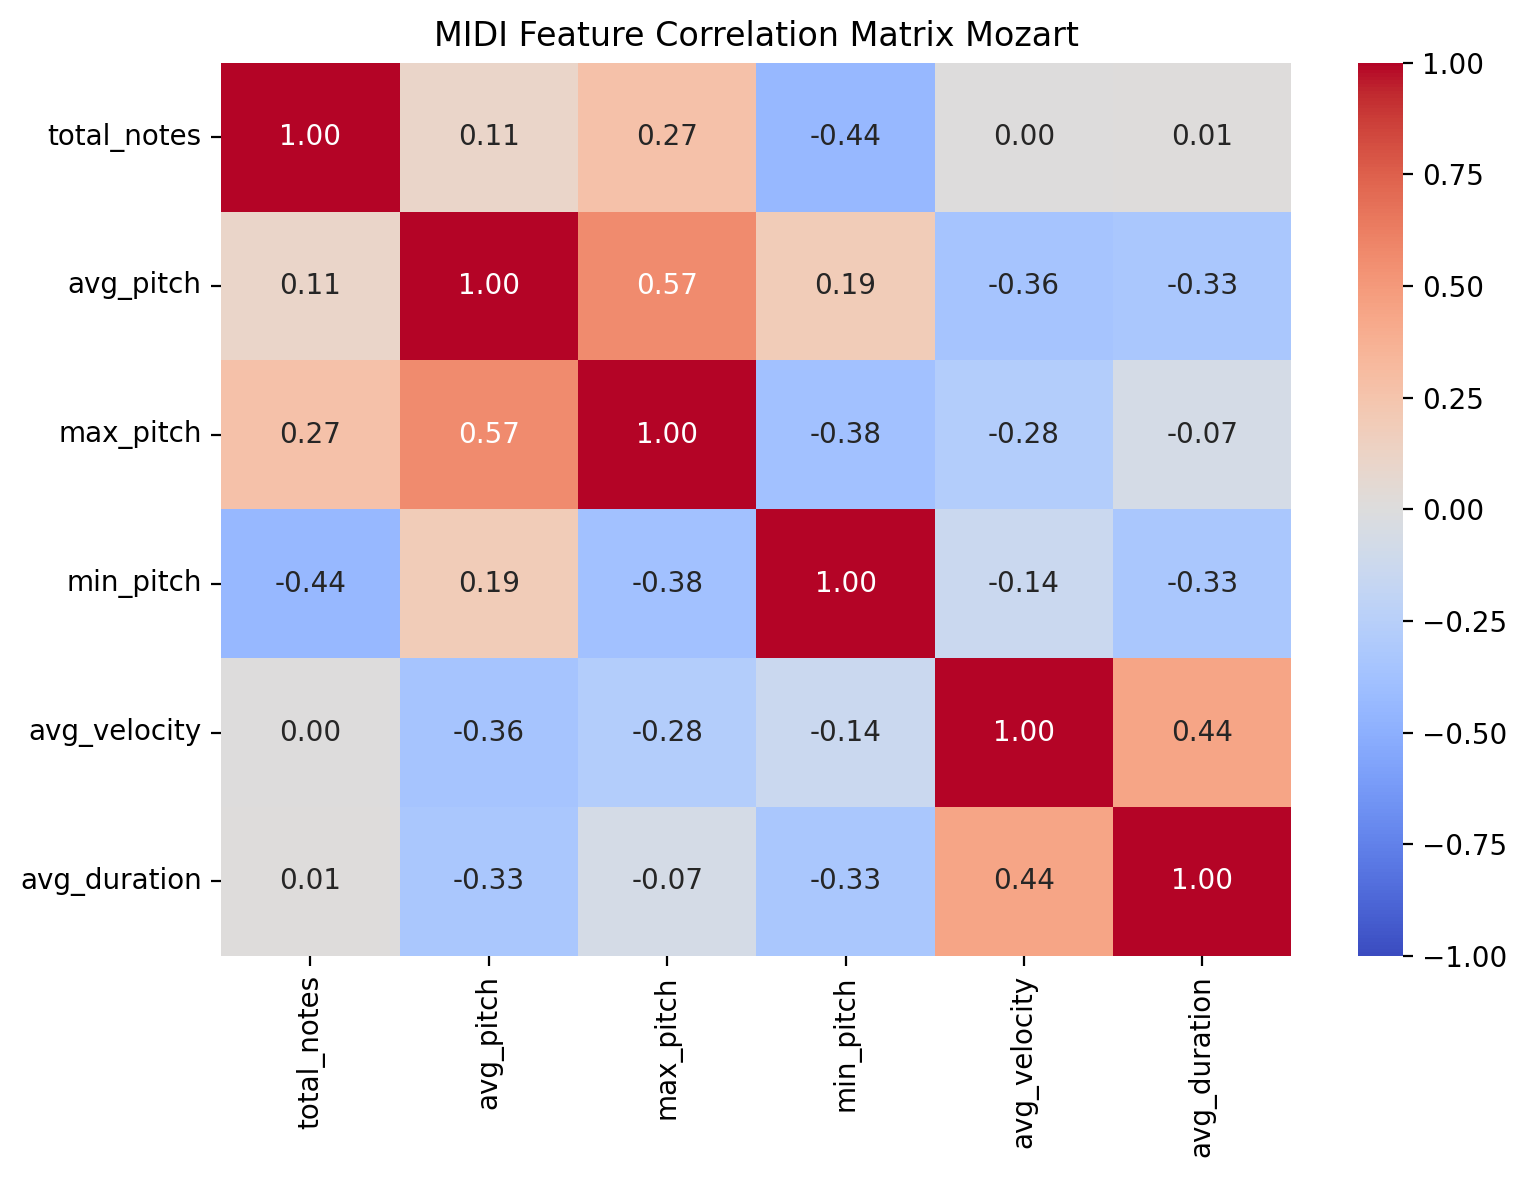

In [29]:
numeric_df = df_mozart[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Mozart')
plt.tight_layout()
plt.show()

              total_notes  avg_pitch  max_pitch  min_pitch  avg_velocity  \
total_notes      1.000000   0.307350   0.674070  -0.473590      0.381379   
avg_pitch        0.307350   1.000000   0.533526   0.191916     -0.076941   
max_pitch        0.674070   0.533526   1.000000  -0.400537      0.319523   
min_pitch       -0.473590   0.191916  -0.400537   1.000000     -0.278883   
avg_velocity     0.381379  -0.076941   0.319523  -0.278883      1.000000   
avg_duration    -0.253382  -0.032377  -0.373878   0.018750     -0.419812   

              avg_duration  
total_notes      -0.253382  
avg_pitch        -0.032377  
max_pitch        -0.373878  
min_pitch         0.018750  
avg_velocity     -0.419812  
avg_duration      1.000000  


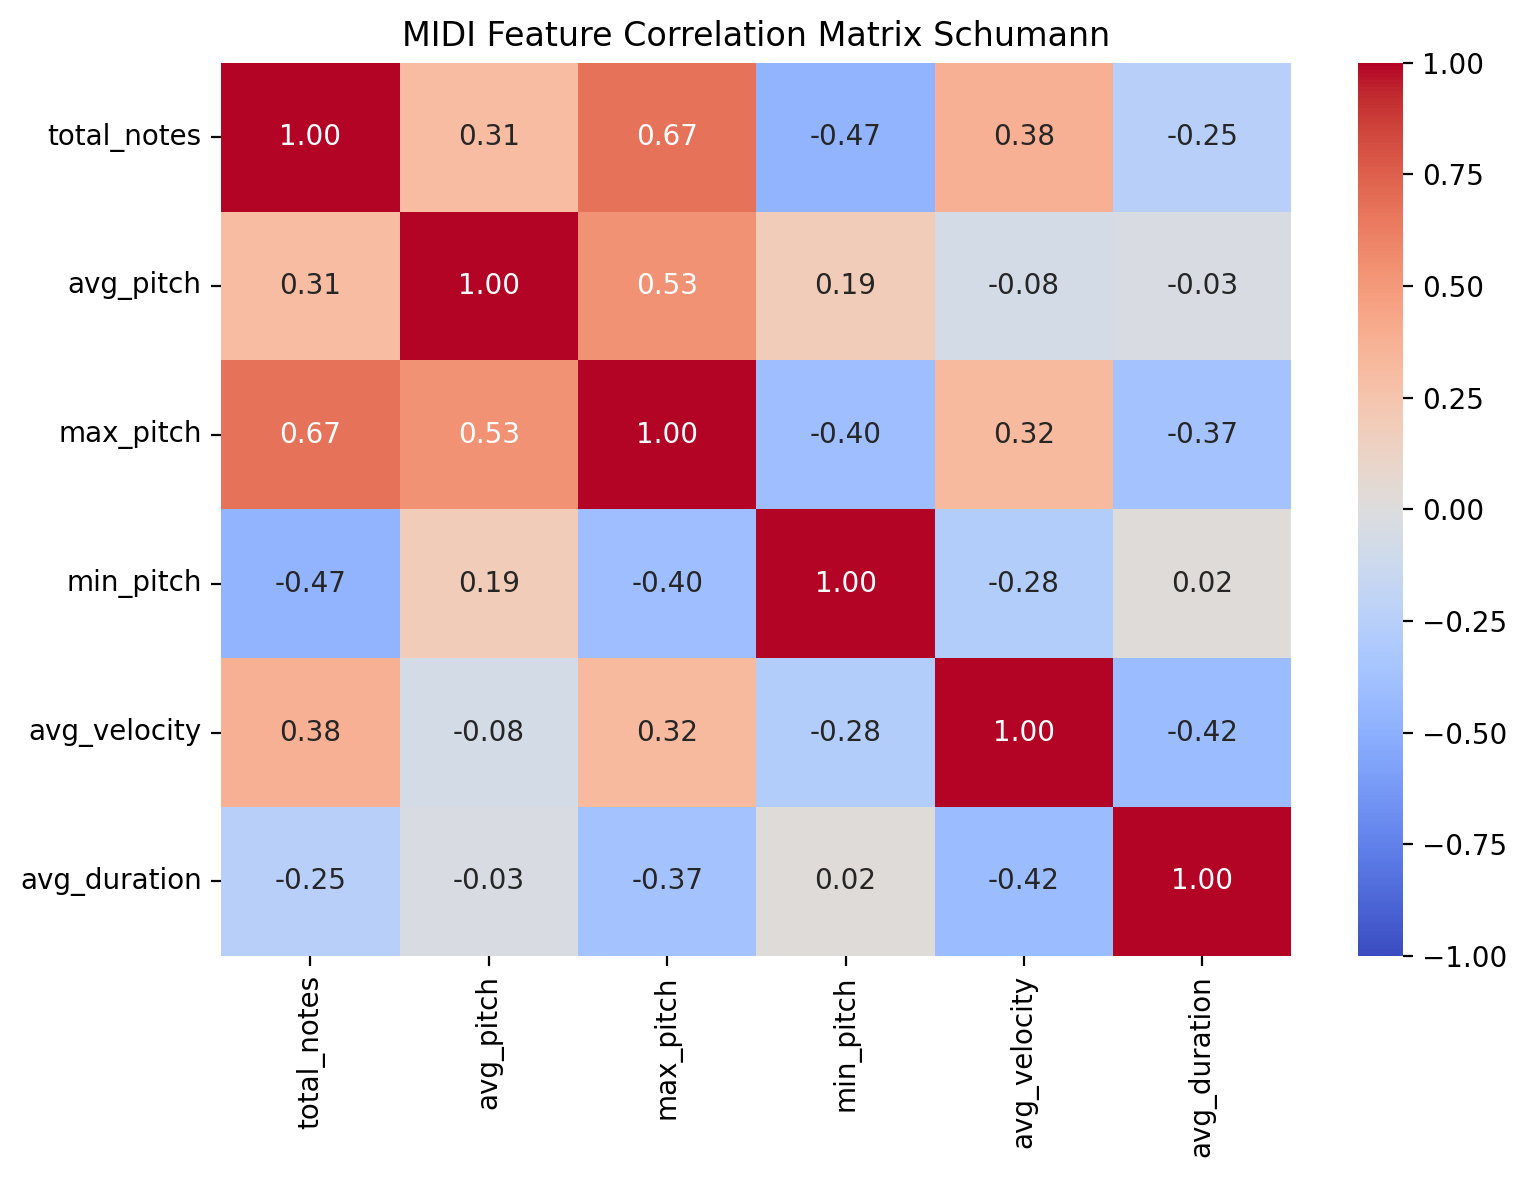

In [30]:
numeric_df = df_schumann[['total_notes', 'avg_pitch', 'max_pitch', 'min_pitch', 'avg_velocity', 'avg_duration']]

# Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Print the raw matrix values
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Red = Positive, Blue = Negative)
    fmt=".2f",           # Limit to 2 decimal places
    vmin=-1, vmax=1      # Color bar between -1 and 1
)

plt.title('MIDI Feature Correlation Matrix Schumann')
plt.tight_layout()
plt.show()

In [1]:
pip install pretty_midi numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=8df21f2b0bd76c5c2873c2f7ce7a91e128a5e5e013c5041b17c89104d29d94e3
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


# CNN Format for midi classification

In [4]:
import os
import glob
import pretty_midi
import numpy as np

def process_midi_for_cnn(file_path, time_steps=100, fs=10):
    try:
        # 1. Load the MIDI file
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # 2. Convert to a Piano Roll matrix and transpose
        piano_roll = midi_data.get_piano_roll(fs=fs).T

        # 3. Chunk into fixed sizes
        chunks = []
        for i in range(0, piano_roll.shape[0] - time_steps, time_steps):
            chunks.append(piano_roll[i:i + time_steps, :])

        if not chunks:
            return None

        processed_data = np.array(chunks)

        # 4. Reshape for CNN: (number_of_chunks, time_steps, pitches, 1 channel)
        processed_data = np.expand_dims(processed_data, axis=-1)
        return processed_data

    except Exception as e:
        # print(f"Error processing {file_path}: {e}")
        return None

def build_cnn_dataset(base_path, time_steps=100, fs=10):
    X = []
    y = []

    # Find all midi files
    midi_files = glob.glob(os.path.join(base_path, '**/*.mid'), recursive=True)

    # Map composer names to integer labels
    composers = sorted(list(set([os.path.basename(os.path.dirname(f)) for f in midi_files])))
    composer_to_id = {c: i for i, c in enumerate(composers)}
    print(f"Found composers: {composer_to_id}")

    print(f"Found {len(midi_files)} MIDI files. Starting processing...")
    for idx, file_path in enumerate(midi_files):
        composer = os.path.basename(os.path.dirname(file_path))
        label = composer_to_id[composer]

        features = process_midi_for_cnn(file_path, time_steps=time_steps, fs=fs)
        if features is not None:
            X.append(features)
            # Extend labels for each chunk
            y.extend([label] * features.shape[0])

        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(midi_files)} files")

    # Stack all chunks together
    X = np.vstack(X) if X else np.array([])
    y = np.array(y)

    return X, y, composer_to_id

train_path = '/content/Composer_Dataset/NN_midi_files_extended/train'

# Uncomment to run the full pipeline (might take a while)
X_train, y_train, label_mapping = build_cnn_dataset(train_path, time_steps=100, fs=10)
print(f"\nFinal Dataset Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


Found composers: {'bach': 0, 'bartok': 1, 'byrd': 2, 'chopin': 3, 'handel': 4, 'hummel': 5, 'mendelssohn': 6, 'mozart': 7, 'schumann': 8}
Found 369 MIDI files. Starting processing...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Processed 50/369 files
Processed 100/369 files
Processed 150/369 files
Processed 200/369 files
Processed 250/369 files
Processed 300/369 files
Processed 350/369 files

Final Dataset Shapes:
X_train shape: (11693, 100, 128, 1)
y_train shape: (11693,)


In [ ]:
    # 1. Load the MIDI file
    midi_data = pretty_midi.PrettyMIDI(file_path)

    # 2. Convert to a Piano Roll matrix (rows = pitches, columns = time)
    # fs is the sampling frequency (e.g., 10 frames per second)
    piano_roll = midi_data.get_piano_roll(fs=fs)

    # piano_roll shape is (128, total_time_frames)
    # We want it to be (total_time_frames, 128)
    piano_roll = piano_roll.T

    # 3. Handle variable song lengths by chunking into fixed sizes
    # Here we divide the song into fixed segments
    chunks = []
    for i in range(0, piano_roll.shape[0] - time_steps, time_steps):
        chunk = piano_roll[i:i + time_steps, :]
        chunks.append(chunk)

    # Stack into a single array
    processed_data = np.array(chunks)

    # 4. Reshape for CNN: (number_of_chunks, time_steps, pitches, 1 channel)
    processed_data = np.expand_dims(processed_data, axis=-1)

    return processed_data

# Example usage:
# features = process_midi_for_cnn("your_song.mid")
# print(features.shape) # Output will be (num_chunks, 100, 128, 1)


In [ ]:
processed_data = process_midi_for_cnn(mid_file)
print(processed_data.shape)